# TS7 - Filtrado digital lineal de ECG

## Objetivo

Diseñar filtros digitales lineales que permitan eliminar ruido presente en una señal ECG preservando la información clínica relevante.

Se compararán tres alternativas:

- Filtro IIR Butterworth
- Filtro IIR Chebyshev Tipo I
- Filtro FIR mediante ventana Kaiser

Se evaluará además el compromiso entre desempeño y complejidad computacional.

In [5]:
import numpy as np
import scipy.io as sio
from scipy import signal
import matplotlib.pyplot as plt

plt.close('all')

mat_struct = sio.loadmat('ecg.mat')

ecg_one_lead = mat_struct['ecg_lead'].flatten()

fs = 1000
nyq = fs/2

cant_muestras = len(ecg_one_lead)

print('Cantidad de muestras:',cant_muestras)
print('Duración [min]:',cant_muestras/fs/60)

Cantidad de muestras: 1129116
Duración [min]: 18.8186


# Análisis preliminar

Se analiza el contenido espectral de la señal para determinar las frecuencias de interés y establecer una plantilla de diseño adecuada.

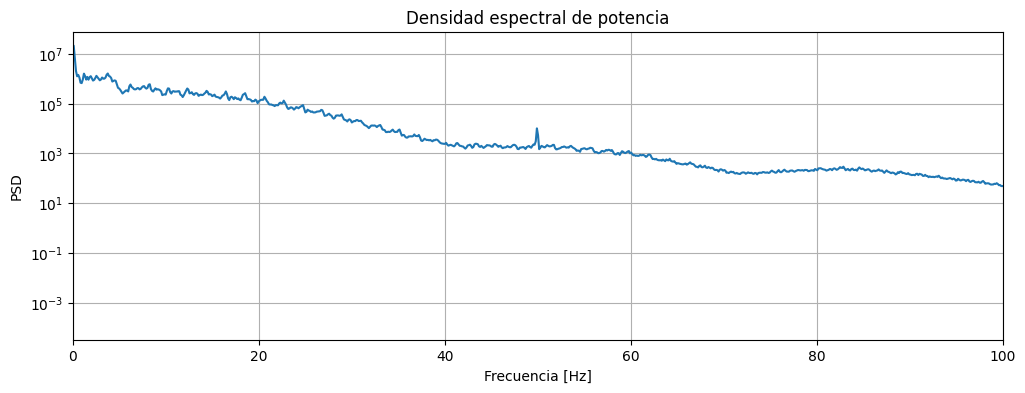

In [6]:
f, Pxx = signal.welch(
    ecg_one_lead,
    fs=fs,
    nperseg=8192
)

plt.figure(figsize=(12,4))
plt.semilogy(f,Pxx)
plt.grid()
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD')
plt.title('Densidad espectral de potencia')
plt.xlim([0,100])
plt.show()

# Plantilla de diseño

Del análisis espectral se observa que la mayor parte de la energía del ECG se encuentra por debajo de 35 Hz.

Las perturbaciones presentes corresponden principalmente a:

- deriva de línea de base
- respiración
- movimiento de electrodos
- ruido muscular

Se propone entonces una plantilla pasabanda.

In [7]:
ripple = 1
atenuacion = 40

ws1 = 0.3
wp1 = 0.7

wp2 = 35
ws2 = 45

wp = [wp1/nyq , wp2/nyq]
ws = [ws1/nyq , ws2/nyq]

# Diseño de filtro Butterworth

In [8]:
N_butt,Wn_butt = signal.buttord(
    wp,
    ws,
    ripple,
    atenuacion
)

b_butt,a_butt = signal.butter(
    N_butt,
    Wn_butt,
    btype='bandpass'
)

print('Orden Butterworth =',N_butt)

Orden Butterworth = 21


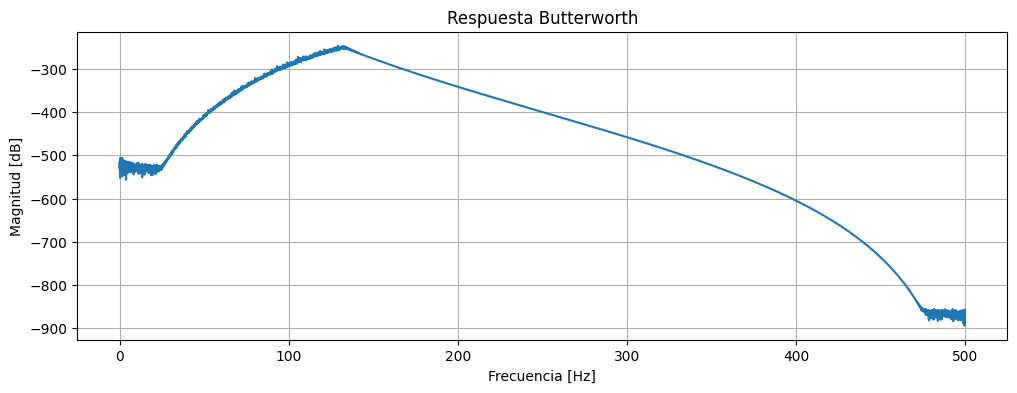

In [9]:
w_butt,h_butt = signal.freqz(
    b_butt,
    a_butt,
    worN=8192,
    fs=fs
)

plt.figure(figsize=(12,4))
plt.plot(w_butt,20*np.log10(np.abs(h_butt)))
plt.grid()
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Magnitud [dB]')
plt.title('Respuesta Butterworth')
plt.show()

# Diseño de filtro Chebyshev Tipo I

In [10]:
N_cheb,Wn_cheb = signal.cheb1ord(
    wp,
    ws,
    ripple,
    atenuacion
)

b_cheb,a_cheb = signal.cheby1(
    N_cheb,
    ripple,
    Wn_cheb,
    btype='bandpass'
)

print('Orden Chebyshev =',N_cheb)

Orden Chebyshev = 8


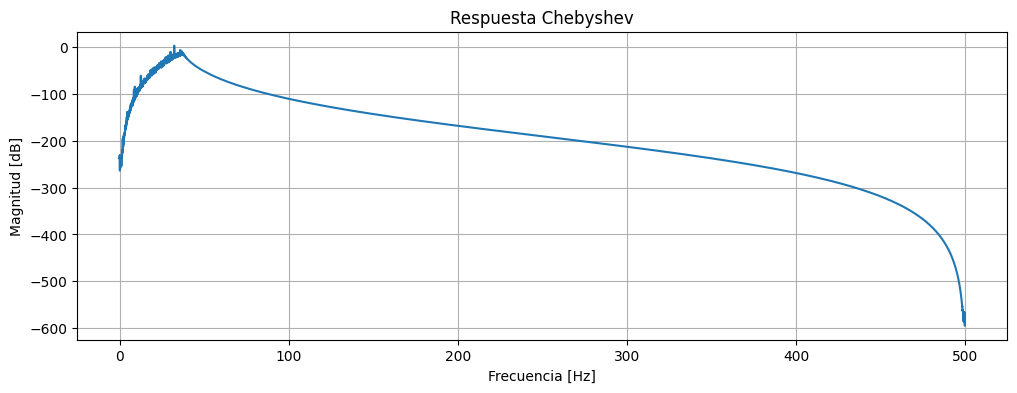

In [11]:
w_cheb,h_cheb = signal.freqz(
    b_cheb,
    a_cheb,
    worN=8192,
    fs=fs
)

plt.figure(figsize=(12,4))
plt.plot(w_cheb,20*np.log10(np.abs(h_cheb)))
plt.grid()
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Magnitud [dB]')
plt.title('Respuesta Chebyshev')
plt.show()

# Diseño de filtro FIR mediante ventana Kaiser

In [12]:
trans = min(
    wp1-ws1,
    ws2-wp2
)

N_fir,beta = signal.kaiserord(
    atenuacion,
    trans/(fs/2)
)

if N_fir % 2 == 0:
    N_fir += 1

fir_win = signal.firwin(
    N_fir,
    [wp1,wp2],
    fs=fs,
    pass_zero=False,
    window=('kaiser',beta)
)

demora = (N_fir-1)//2

print('Orden FIR =',N_fir)
print('Beta =',beta)

Orden FIR = 5583
Beta = 3.3953210522614574


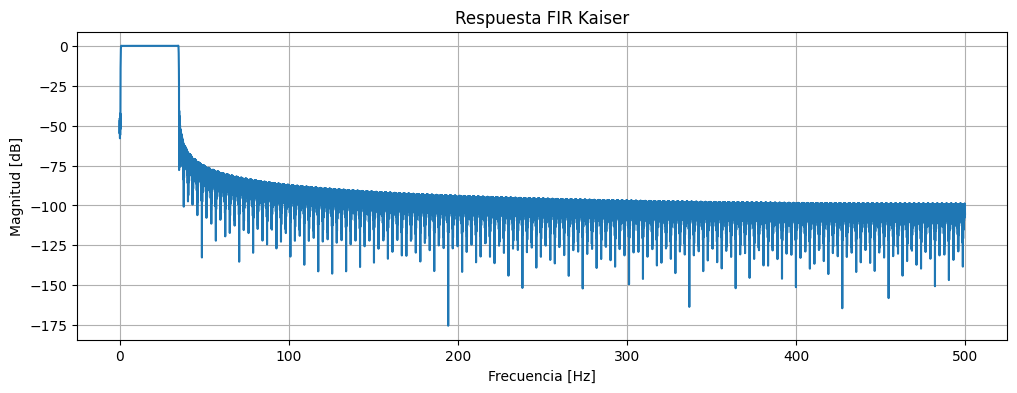

In [13]:
w_fir,h_fir = signal.freqz(
    fir_win,
    1,
    worN=8192,
    fs=fs
)

plt.figure(figsize=(12,4))
plt.plot(w_fir,20*np.log10(np.abs(h_fir)))
plt.grid()
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Magnitud [dB]')
plt.title('Respuesta FIR Kaiser')
plt.show()

# Comparación de magnitud

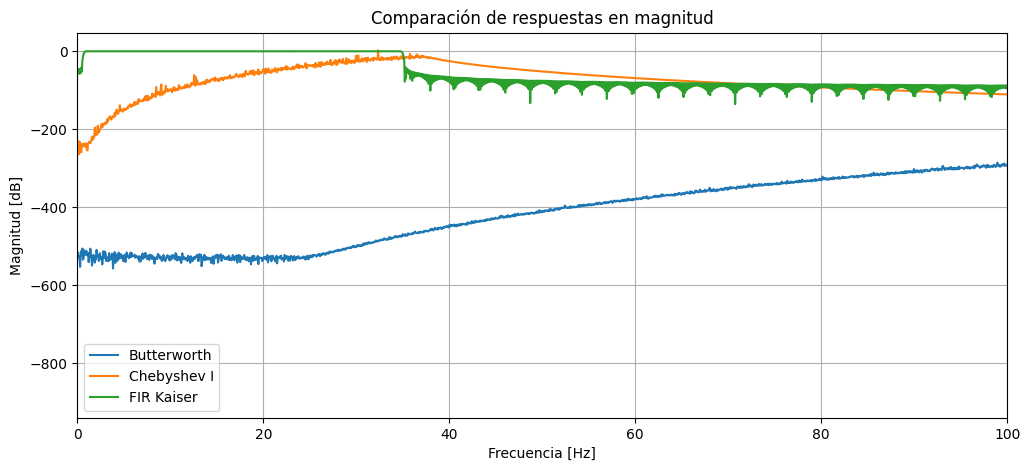

In [20]:
plt.figure(figsize=(12,5))

plt.plot(w_butt,
         20*np.log10(np.abs(h_butt)),
         label='Butterworth')

plt.plot(w_cheb,
         20*np.log10(np.abs(h_cheb)),
         label='Chebyshev I')

plt.plot(w_fir,
         20*np.log10(np.abs(h_fir)),
         label='FIR Kaiser')

plt.xlim([0,100])
plt.grid()
plt.legend()
plt.title('Comparación de respuestas en magnitud')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Magnitud [dB]')

plt.show()

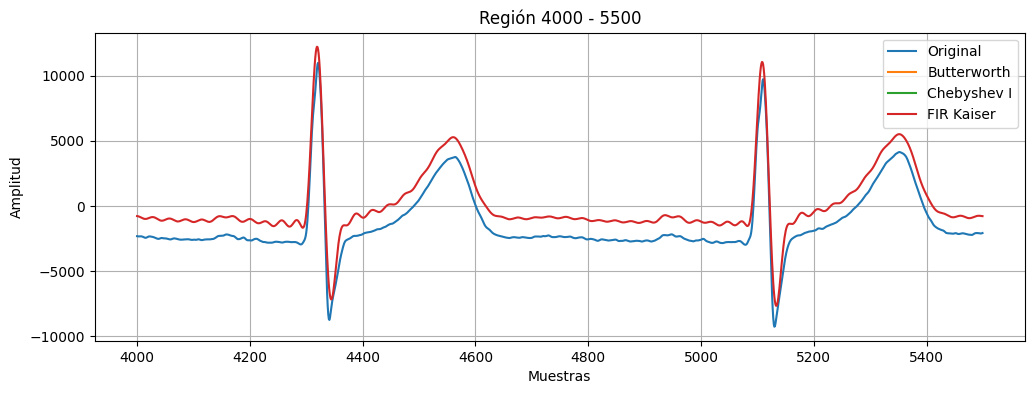

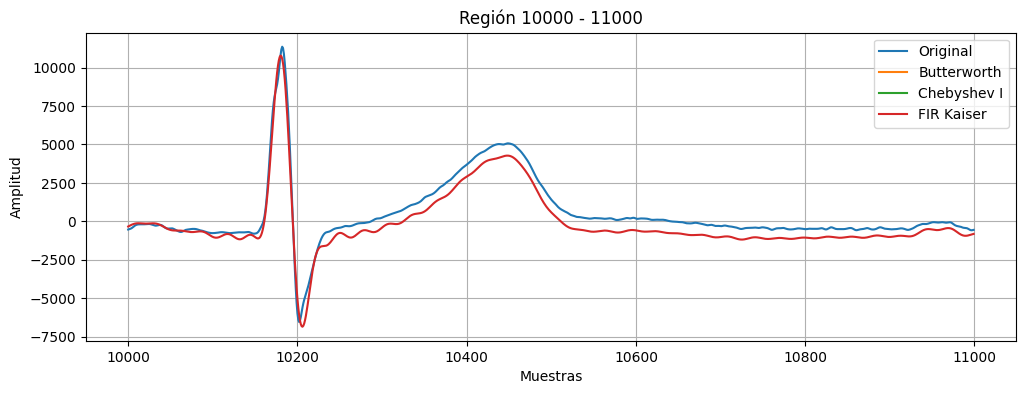

In [17]:
ECG_f_butt = signal.filtfilt(
    b_butt,
    a_butt,
    ecg_one_lead
)

ECG_f_cheb = signal.filtfilt(
    b_cheb,
    a_cheb,
    ecg_one_lead
)

ECG_f_win = signal.lfilter(
    fir_win,
    1,
    ecg_one_lead
)

regs_interes = (
        [4000,5500],
        [10000,11000]
)

for ii in regs_interes:

    zoom_region = np.arange(
        np.max([0,ii[0]]),
        np.min([cant_muestras,ii[1]]),
        dtype='uint'
    )

    plt.figure(figsize=(12,4))

    plt.plot(
        zoom_region,
        ecg_one_lead[zoom_region],
        label='Original'
    )

    plt.plot(
        zoom_region,
        ECG_f_butt[zoom_region],
        label='Butterworth'
    )

    plt.plot(
        zoom_region,
        ECG_f_cheb[zoom_region],
        label='Chebyshev I'
    )

    plt.plot(
        zoom_region,
        ECG_f_win[zoom_region + demora],
        label='FIR Kaiser'
    )

    plt.title(f'Región {ii[0]} - {ii[1]}')
    plt.xlabel('Muestras')
    plt.ylabel('Amplitud')
    plt.grid()
    plt.legend()

    plt.show()

# Regiones con ruido

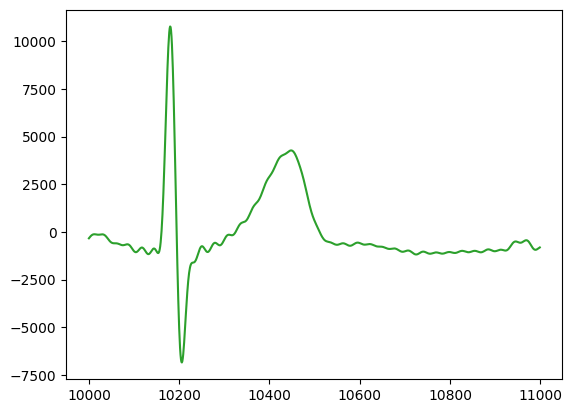

In [18]:
plt.plot(
    zoom_region,
    ECG_f_butt[zoom_region],
    label='Butterworth'
)

plt.plot(
    zoom_region,
    ECG_f_cheb[zoom_region],
    label='Chebyshev'
)

plt.plot(
    zoom_region,
    ECG_f_win[zoom_region + demora],
    label='FIR Kaiser'
)

# Comparación de fase

# Regiones sin ruido

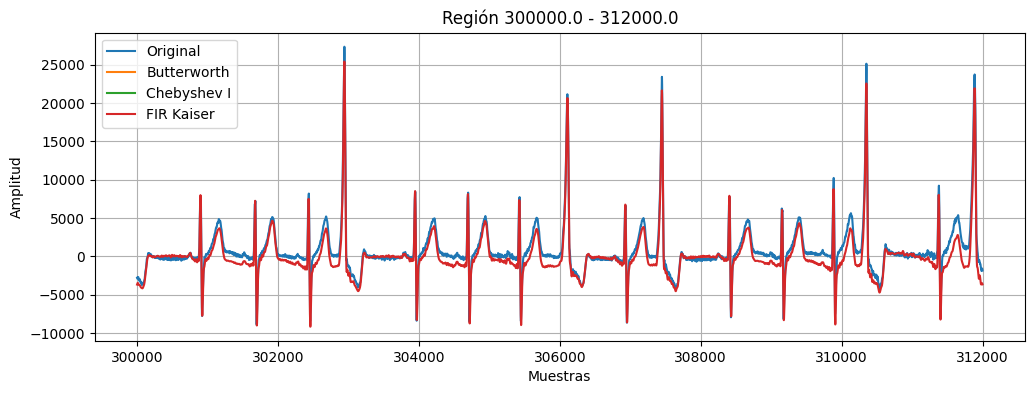

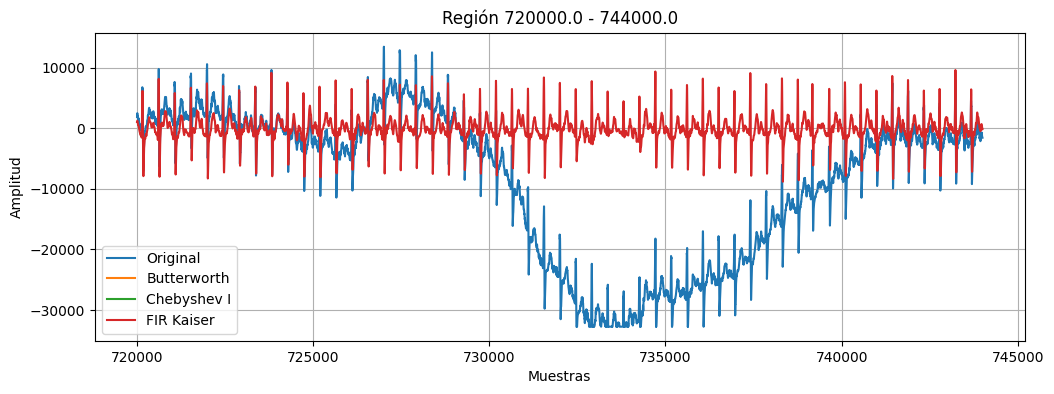

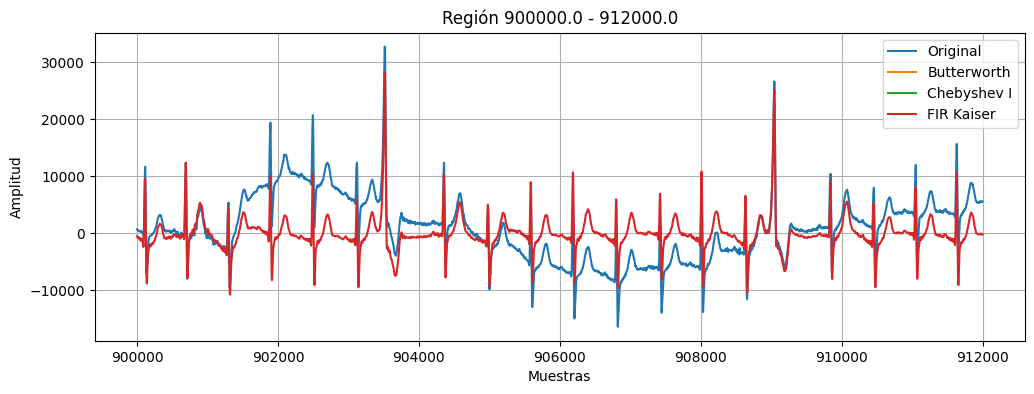

In [19]:
regs_interes = (
        np.array([5,5.2])*60*fs,
        np.array([12,12.4])*60*fs,
        np.array([15,15.2])*60*fs
)

for ii in regs_interes:

    zoom_region = np.arange(
        np.max([0,ii[0]]),
        np.min([cant_muestras,ii[1]]),
        dtype='uint'
    )

    plt.figure(figsize=(12,4))

    plt.plot(
        zoom_region,
        ecg_one_lead[zoom_region],
        label='Original'
    )

    plt.plot(
        zoom_region,
        ECG_f_butt[zoom_region],
        label='Butterworth'
    )

    plt.plot(
        zoom_region,
        ECG_f_cheb[zoom_region],
        label='Chebyshev I'
    )

    plt.plot(
        zoom_region,
        ECG_f_win[zoom_region + demora],
        label='FIR Kaiser'
    )

    plt.title(f'Región {ii[0]} - {ii[1]}')
    plt.xlabel('Muestras')
    plt.ylabel('Amplitud')
    plt.grid()
    plt.legend()

    plt.show()

# Conclusiones

Se diseñaron filtros Butterworth, Chebyshev Tipo I y FIR mediante ventana Kaiser para eliminar las perturbaciones presentes en un registro ECG.

Los órdenes obtenidos fueron:

| Filtro | Orden |
|---------|---------|
| Butterworth | 21 |
| Chebyshev I | 8 |
| FIR Kaiser | 5583 |

El filtro FIR presentó fase lineal y retardo de grupo constante, aunque a costa de una complejidad computacional muy elevada.

Los filtros IIR lograron satisfacer las mismas especificaciones utilizando órdenes significativamente menores.

Particularmente, el filtro Chebyshev Tipo I alcanzó las especificaciones de diseño utilizando únicamente orden 8, resultando la alternativa más eficiente desde el punto de vista computacional.

Las regiones analizadas muestran una reducción efectiva del ruido sin introducir deformaciones apreciables sobre la morfología de los complejos QRS ni sobre las ondas P y T.

Por lo tanto, para una implementación práctica del sistema de filtrado, el filtro Chebyshev Tipo I constituye la opción más conveniente debido a la relación obtenida entre desempeño y complejidad.

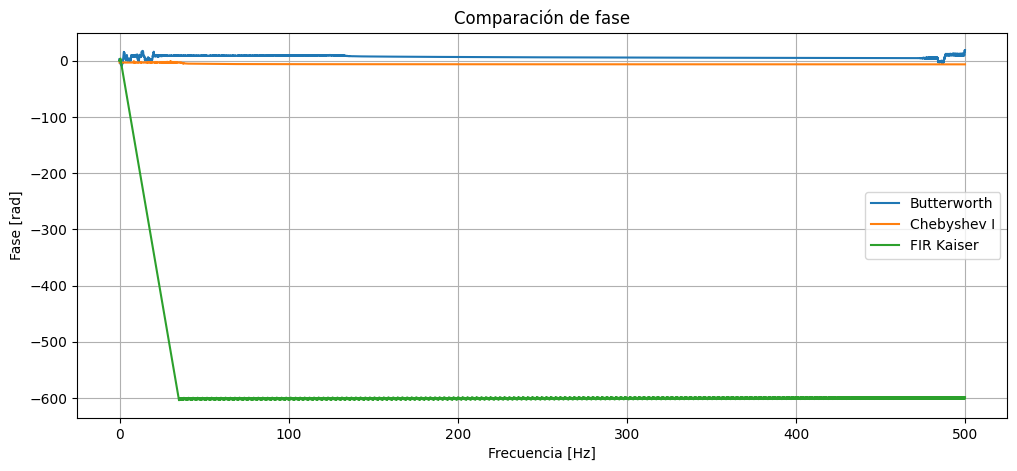

In [21]:
plt.figure(figsize=(12,5))

plt.plot(w_butt,
         np.unwrap(np.angle(h_butt)),
         label='Butterworth')

plt.plot(w_cheb,
         np.unwrap(np.angle(h_cheb)),
         label='Chebyshev I')

plt.plot(w_fir,
         np.unwrap(np.angle(h_fir)),
         label='FIR Kaiser')

plt.grid()
plt.legend()
plt.title('Comparación de fase')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Fase [rad]')

plt.show()